# Nama: Arya Ferdiansyah Putra
# NIM: 4222301074
# Kelas: Robotika Pagi C

In [6]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

## Load Our Dataset

In [7]:
df = pd.read_csv('wine/WineQT.csv')

## EDA

Text(0.5, 1.0, 'Sebaran Nilai pH vs Alcohol')

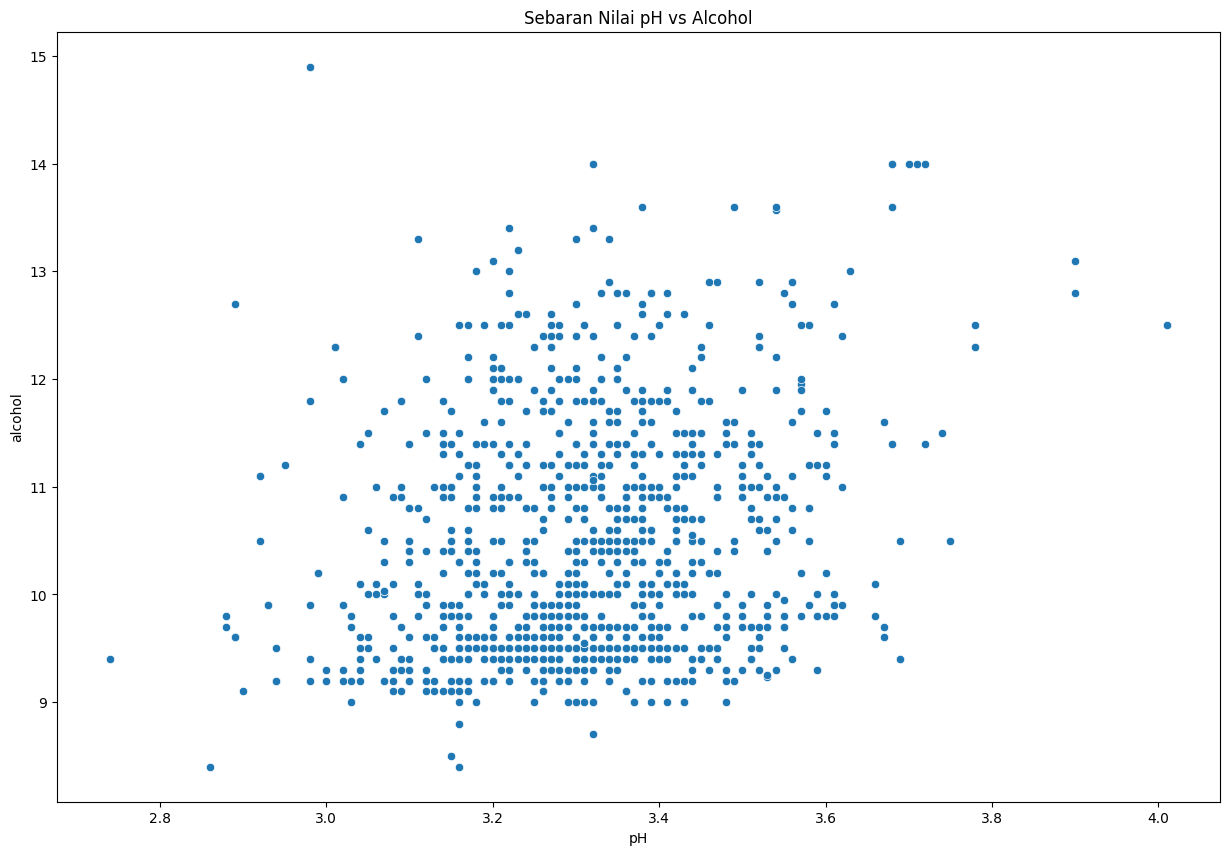

In [8]:
fig, ax = plt.subplots(figsize=(15,10))
sns.scatterplot(data=df, x='pH', y='alcohol')
plt.title('Sebaran Nilai pH vs Alcohol')

In [9]:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
count,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000
mean,8.311111,0.531339,0.268364,2.532152,0.086933,15.615486,45.914698,0.996730,3.311015,0.657708,10.442111,5.657043,804.969379
std,1.747595,0.179633,0.196686,1.355917,0.047267,10.250486,32.782130,0.001925,0.156664,0.170399,1.082196,0.805824,463.997116
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000,0.000000
25%,7.100000,0.392500,0.090000,1.900000,0.070000,7.000000,21.000000,0.995570,3.205000,0.550000,9.500000,5.000000,411.000000
50%,7.900000,0.520000,0.250000,2.200000,0.079000,13.000000,37.000000,0.996680,3.310000,0.620000,10.200000,6.000000,794.000000
75%,9.100000,0.640000,0.420000,2.600000,0.090000,21.000000,61.000000,0.997845,3.400000,0.730000,11.100000,6.000000,1209.500000
max,15.900000,1.580000,1.000000,15.500000,0.611000,68.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000,1597.000000


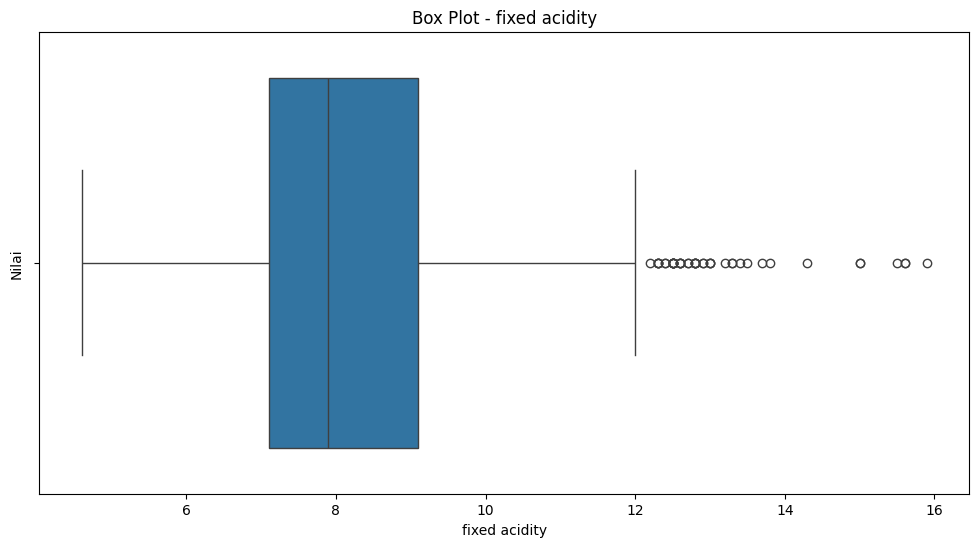

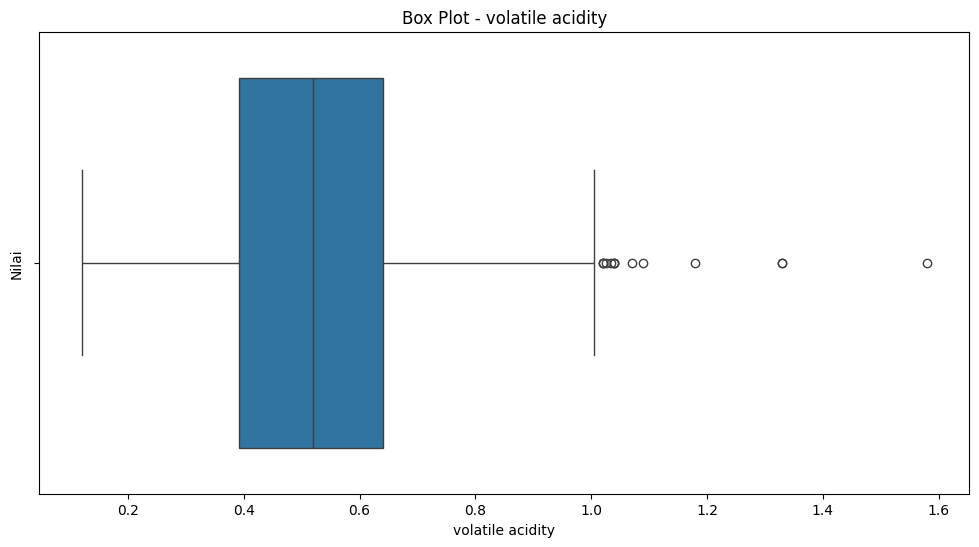

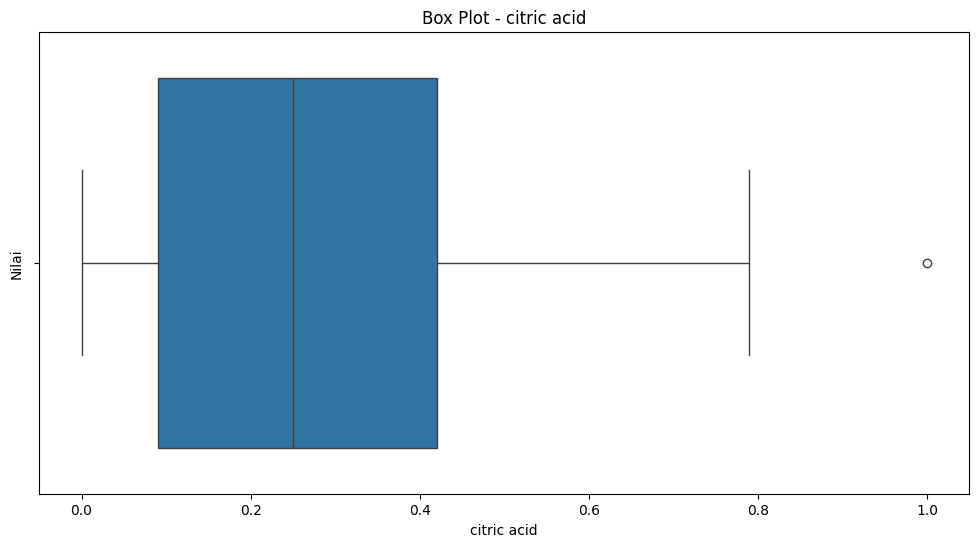

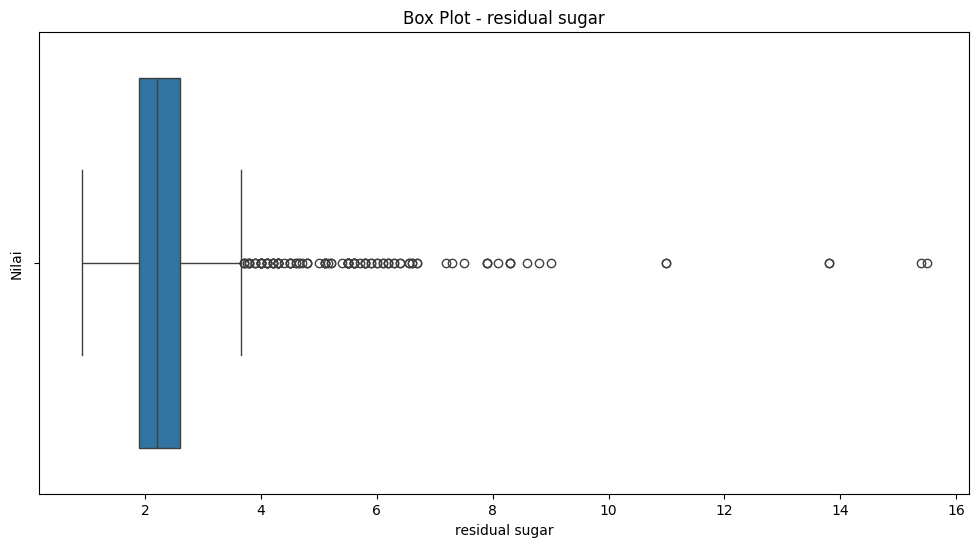

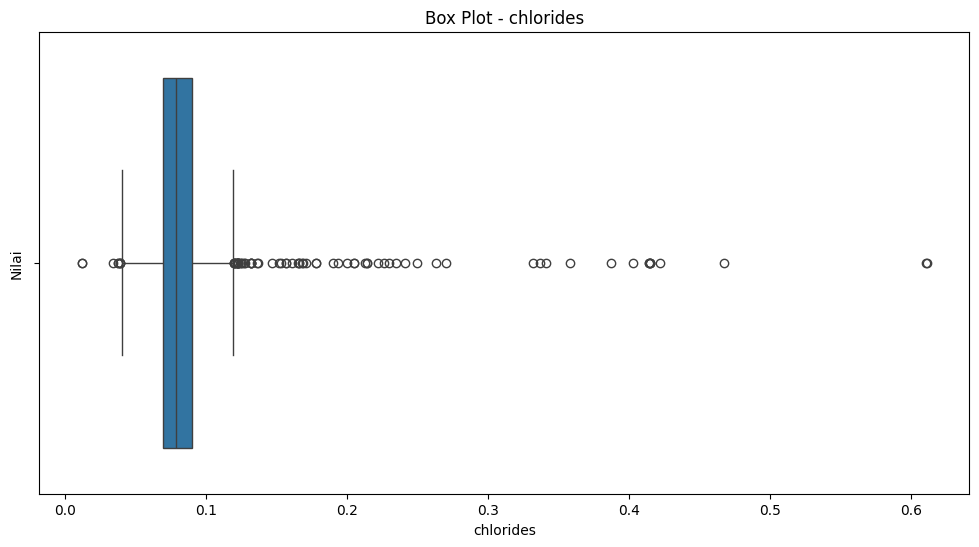

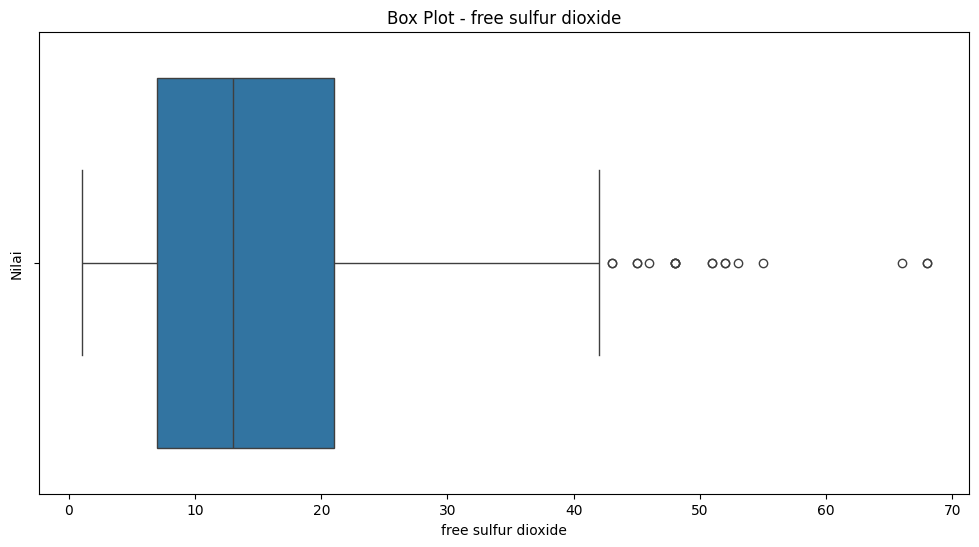

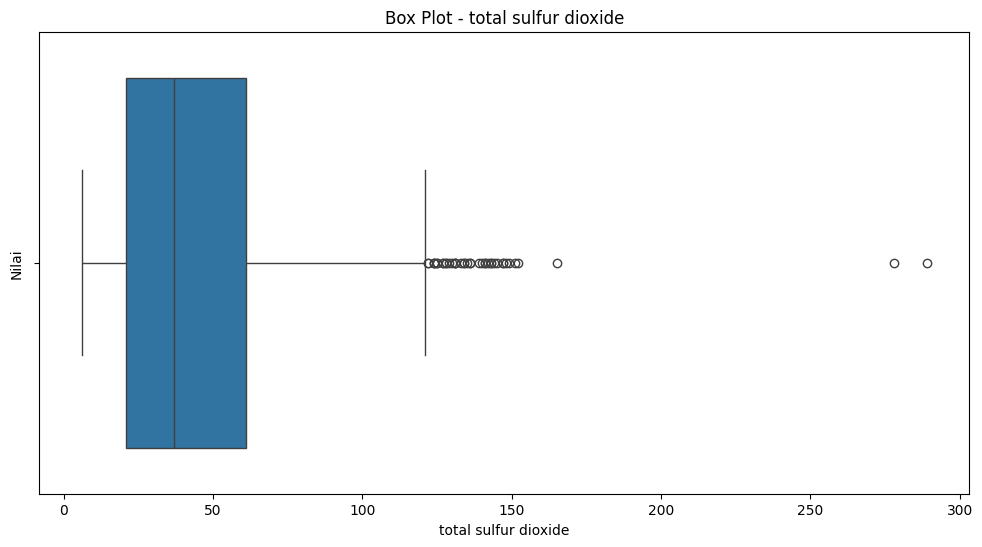

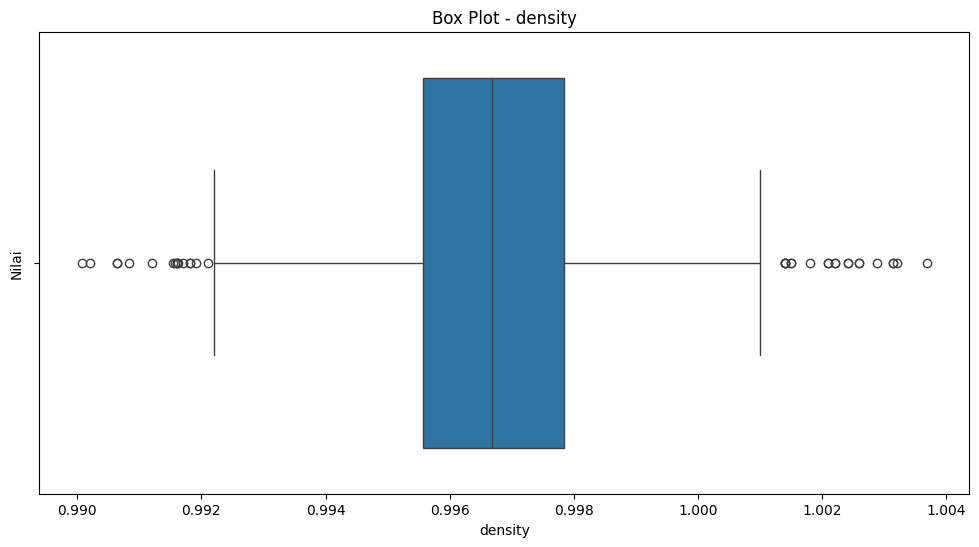

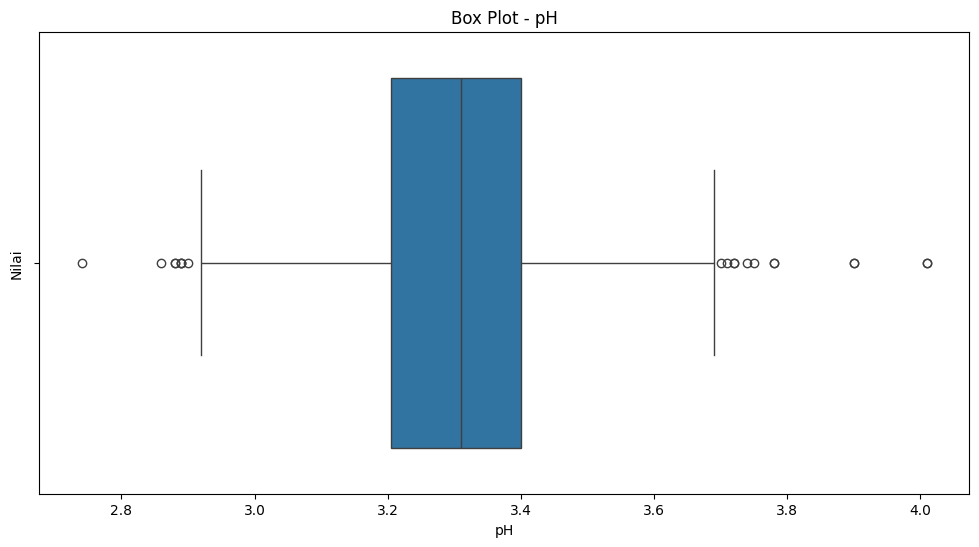

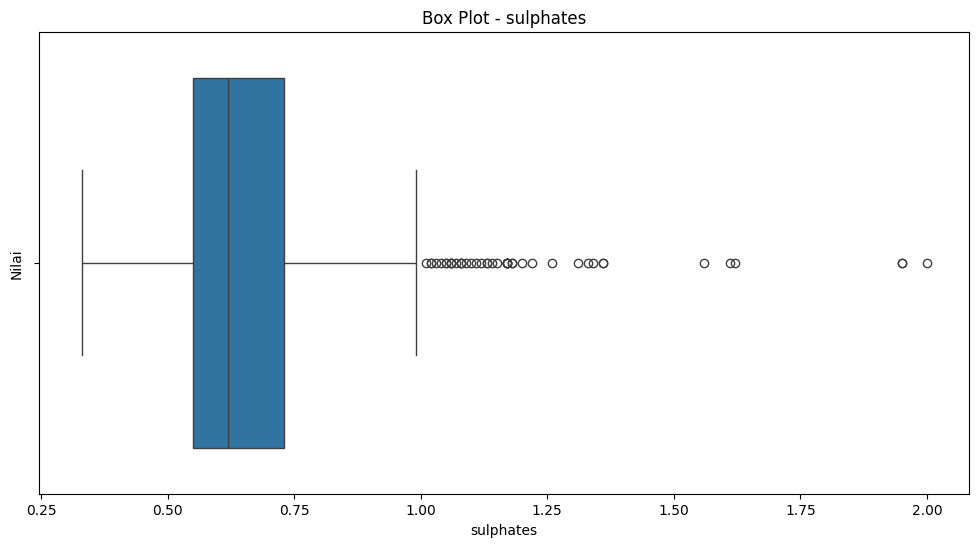

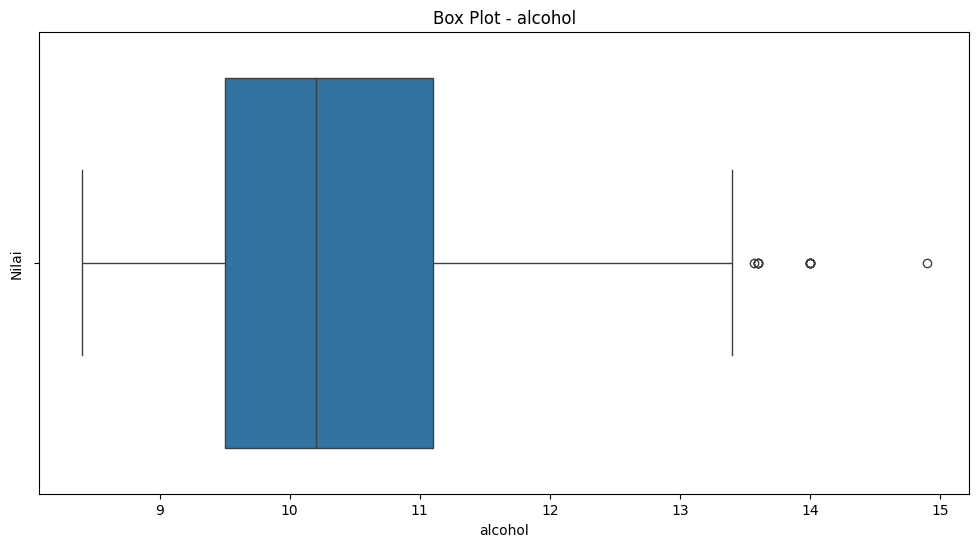

In [10]:
columns = [
    'fixed acidity',
    'volatile acidity',
    'citric acid',
    'residual sugar',
    'chlorides',
    'free sulfur dioxide',
    'total sulfur dioxide',
    'density',
    'pH',
    'sulphates',
    'alcohol'
]

for col in columns:
    plt.figure(figsize=(12, 6))
    sns.boxplot(x=col, data=df)

    plt.title(f'Box Plot - {col}')
    plt.xlabel(col)
    plt.ylabel('Nilai')

    plt.show()

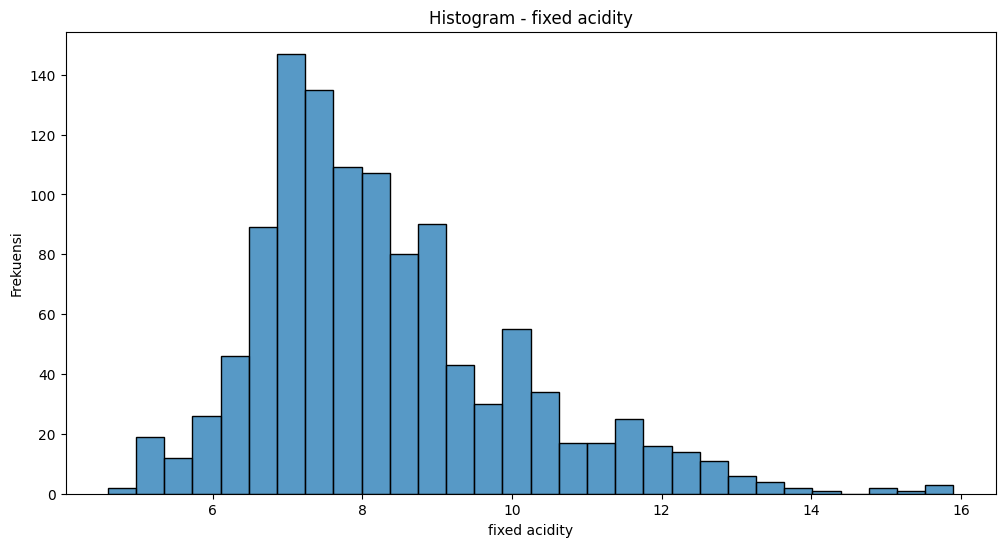

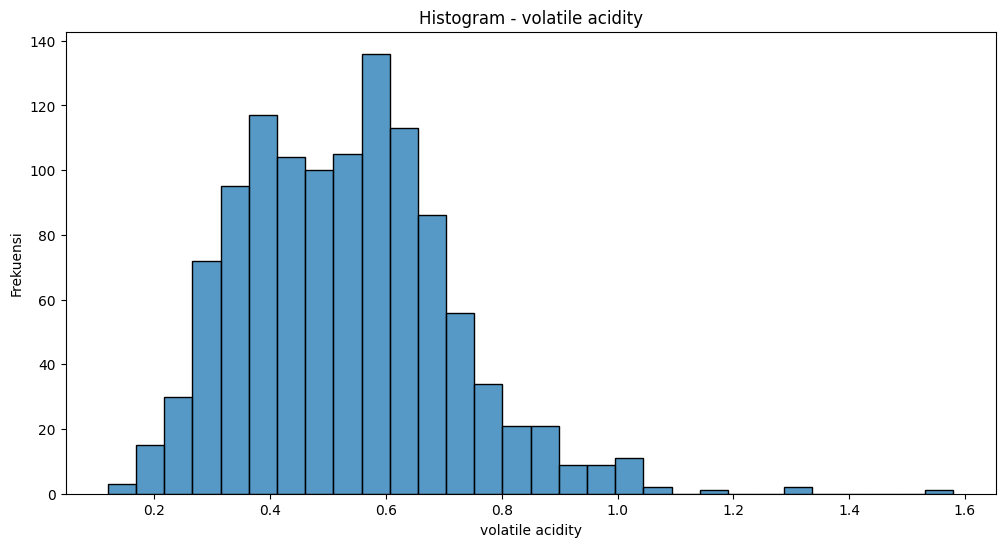

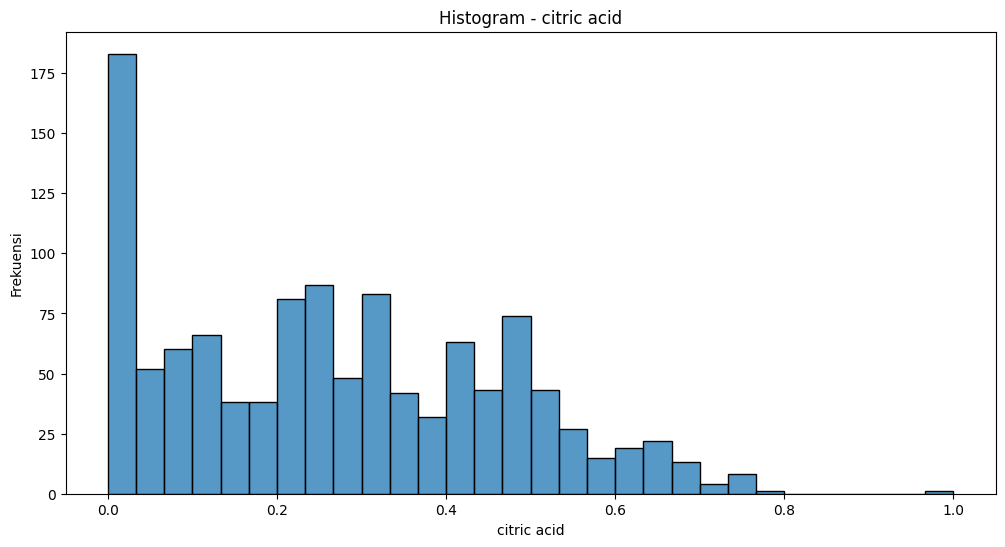

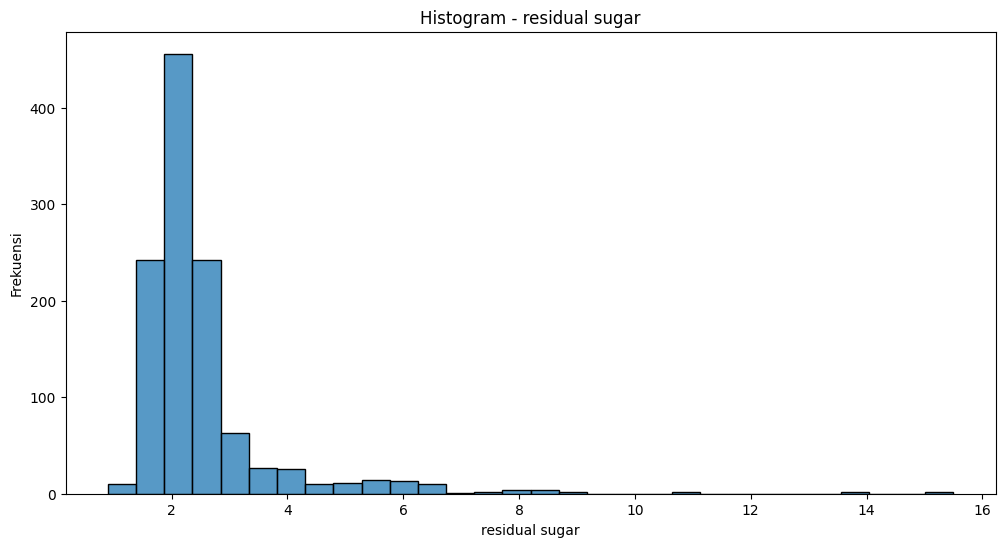

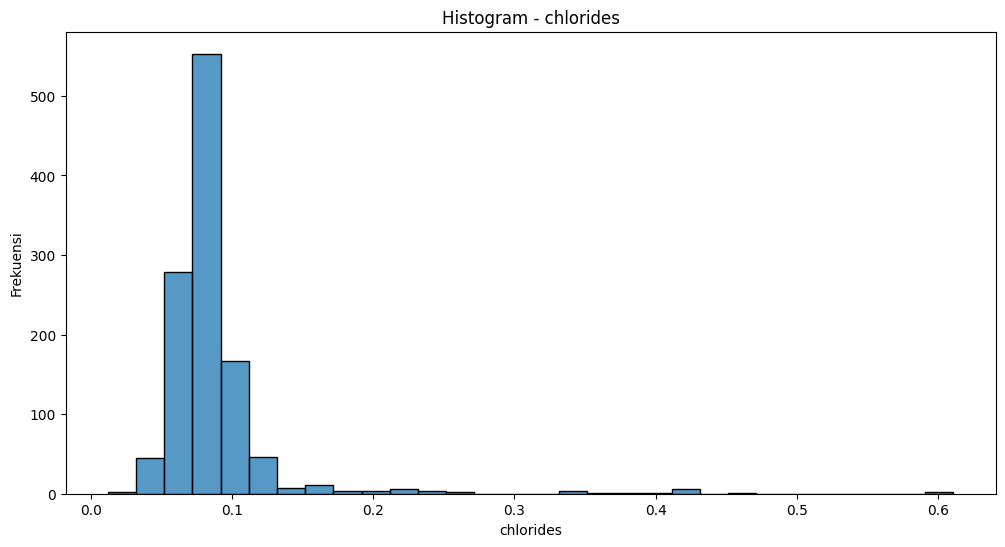

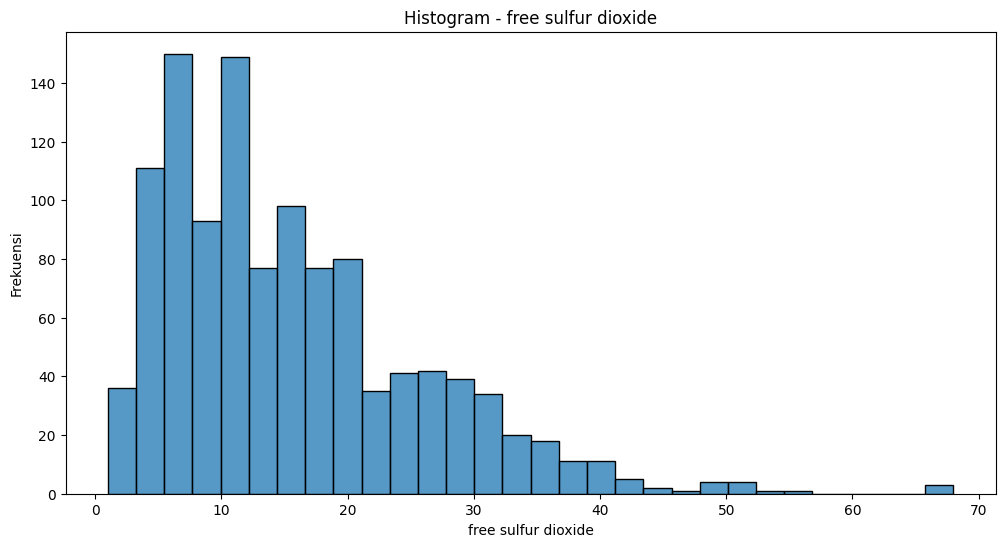

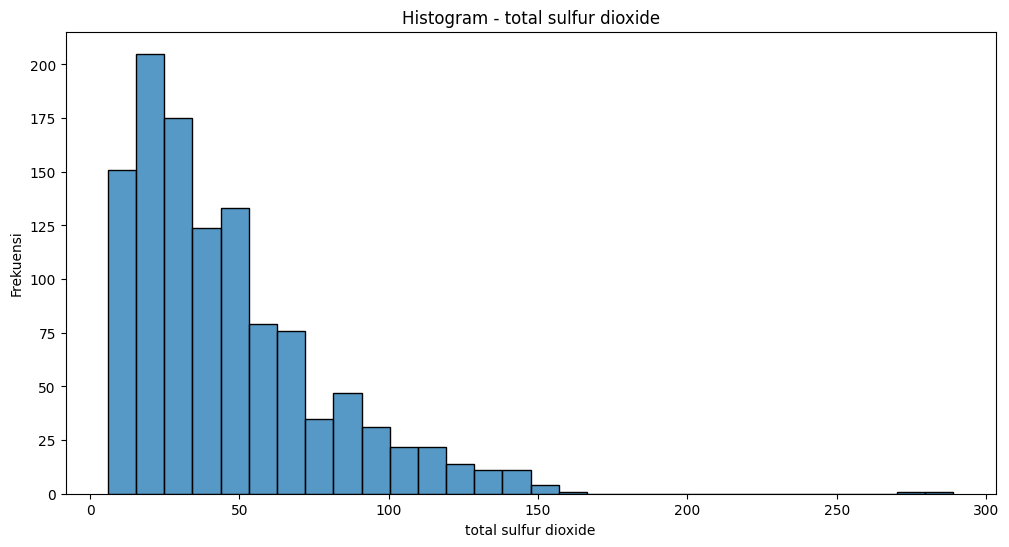

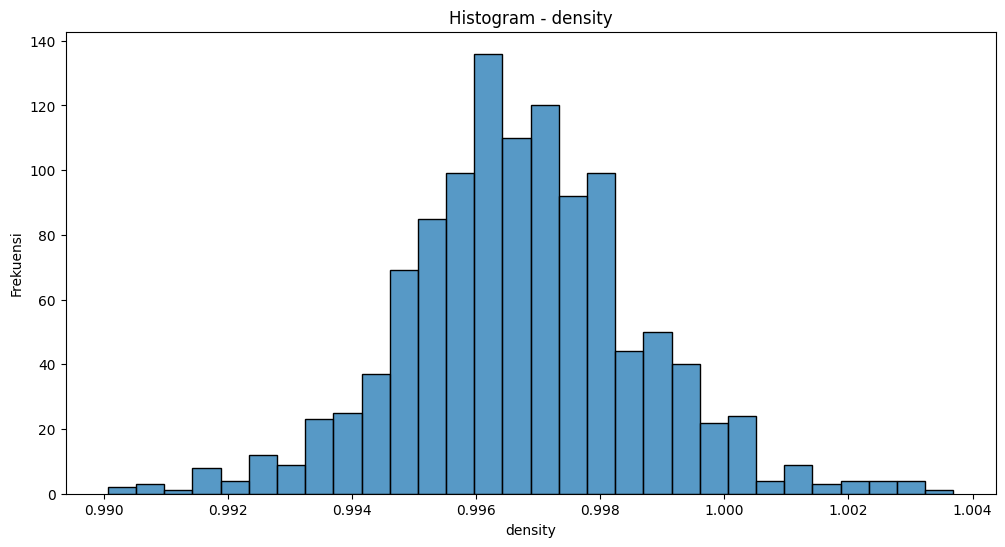

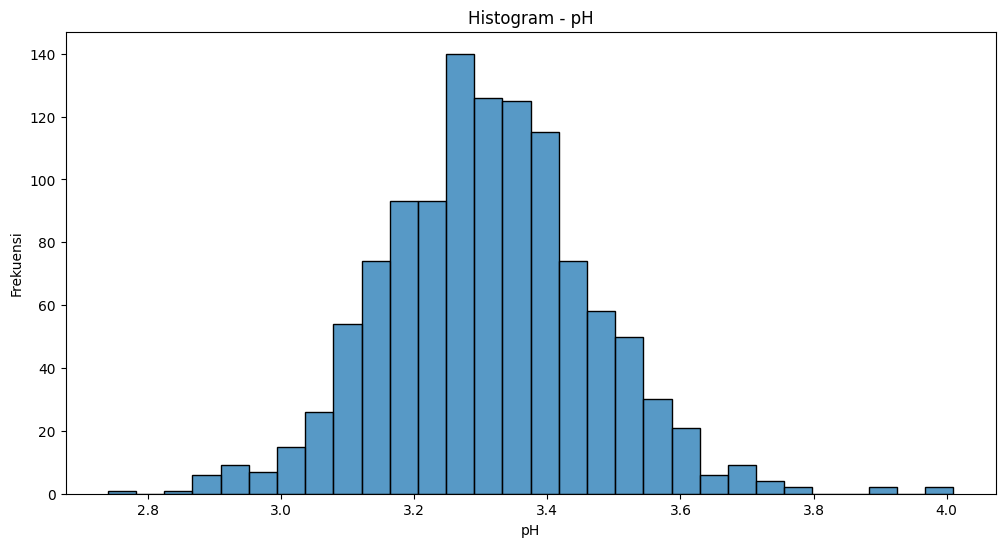

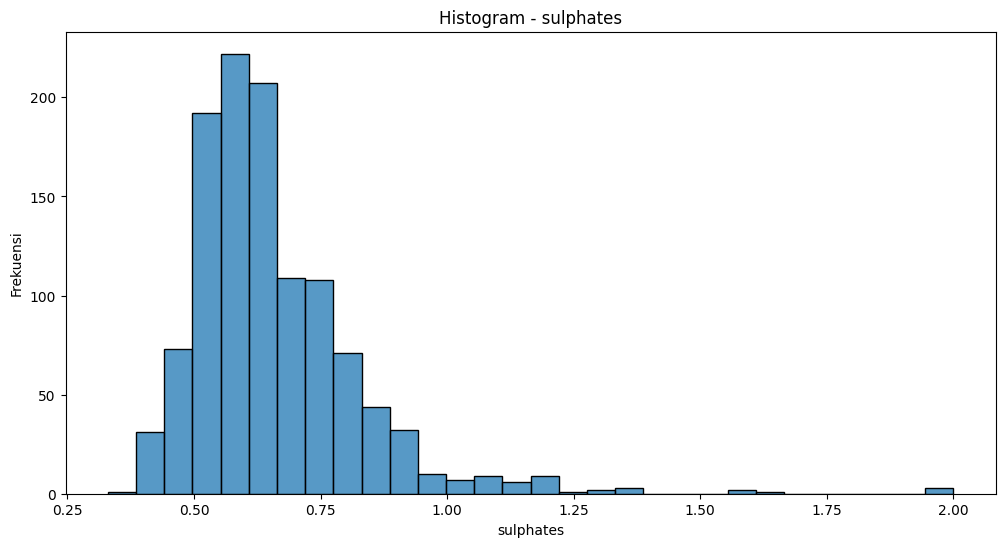

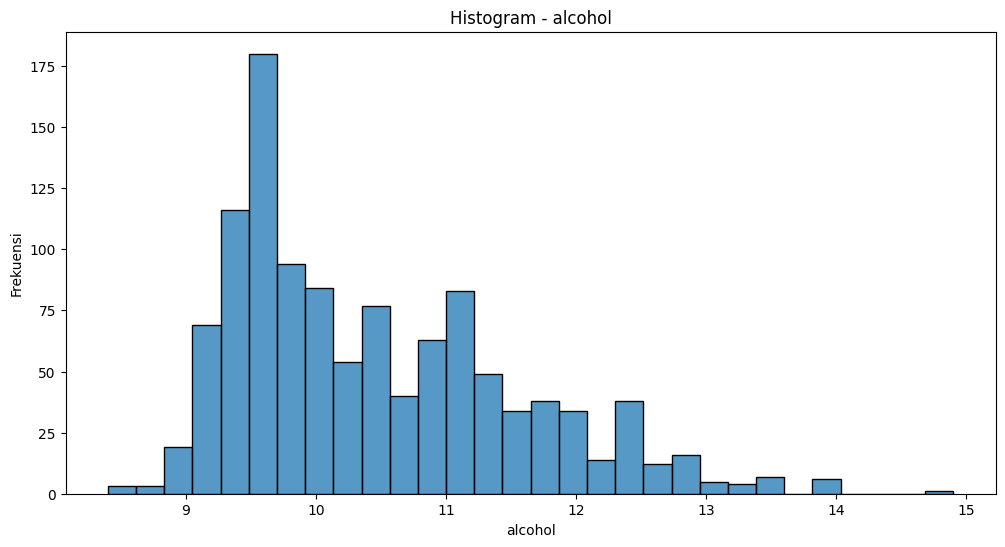

In [11]:
for col in columns:
    # Histogram
    plt.figure(figsize=(12, 6))
    sns.histplot(df[col], bins=30, kde=False)

    plt.title(f'Histogram - {col}')
    plt.xlabel(col)
    plt.ylabel('Frekuensi')

    plt.show()

## Feature Engineering
* Unsupervised tidak perlu dilakukan splitting
1. Drop Duplikat
2. Outlier Handling (opsional)-> pada step ini tidak perlu, karena berat dan tinggi masih wajar untuk nilai seperti itu
3. Feature Scalling

In [12]:
# Drop Duplicates

print(f"Dataframe dimension before duplication drop {df.shape[0]}")

df = df.drop_duplicates().reset_index(drop=True)

print(f"Dataframe dimension after duplication drop {df.shape[0]}")

Dataframe dimension before duplication drop 1143
Dataframe dimension after duplication drop 1143


dari hasil running program diatas, tidak ada data yg duplikat

In [13]:
fitur_columns = ['pH', 'alcohol']
X = df[fitur_columns].values
y = df['Id'].values #anotator label

In [14]:
# Feature Scalling
from sklearn.preprocessing import StandardScaler
X_std = StandardScaler().fit_transform(X)
df_scalling = pd.DataFrame(data = X_std, columns = fitur_columns )
df_scalling.describe()

,pH,alcohol
count,1.143000e+03,1.143000e+03
mean,-8.454402e-16,-1.193563e-15
std,1.000438e+00,1.000438e+00
min,-3.646432e+00,-1.887834e+00
25%,-6.769982e-01,-8.709366e-01
50%,-6.480857e-03,-2.238203e-01
75%,5.682483e-01,6.081863e-01
max,4.463634e+00,4.121103e+00


In [15]:
X_std

array([[ 1.27069495, -0.96338181],
       [-0.70892755, -0.59360107],
       [-0.32577481, -0.59360107],
       ...,
       [ 0.88754221,  0.05351522],
       [ 1.33455374,  0.70063152],
       [ 1.65384769, -0.22382033]], shape=(1143, 2))

In [16]:
df_scalling

,pH,alcohol
0,1.270695,-0.963382
1,-0.708928,-0.593601
2,-0.325775,-0.593601
3,-0.964363,-0.593601
4,1.270695,-0.963382
...,...,...
1138,0.695966,0.515741
1139,0.695966,-0.870937
1140,0.887542,0.053515
1141,1.334554,0.700632


## TO DO!
- Lengkapi Code dibawah ini, untuk mengecek distribusi sebelum dan setelah dilakukan feature scalling menggunakan standar scaller

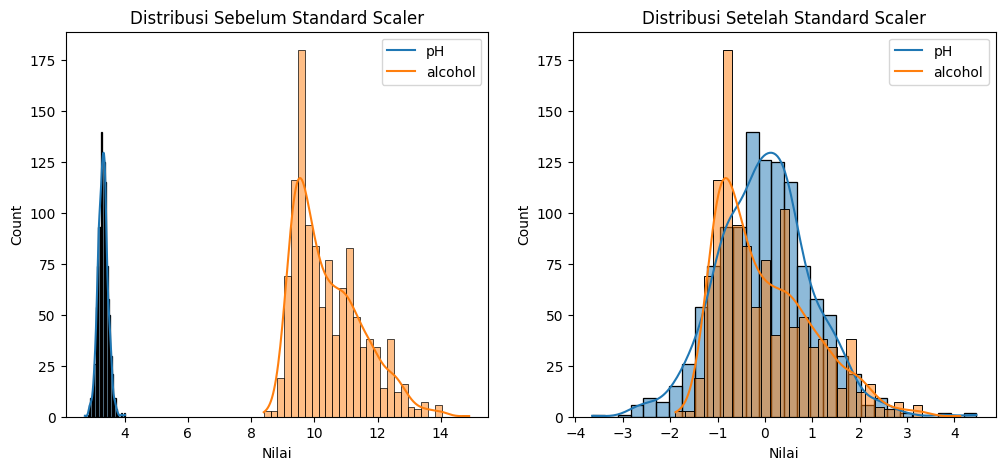

In [17]:
# cek grafik sebelum dan setelah scaling
# kita lihat distribusi variabel sebelum standard scaler dan setelah standard scaler

fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

# Plot distribusi sebelum Standard Scaler
sns.histplot(df['pH'], bins=30, kde=True, ax=ax1)
sns.histplot(df['alcohol'], bins=30, kde=True, ax=ax1)
ax1.set_title('Distribusi Sebelum Standard Scaler')

# Plot distribusi setelah Standard Scaler
sns.histplot(df_scalling['pH'], bins=30, kde=True, ax=ax2)
sns.histplot(df_scalling['alcohol'], bins=30, kde=True, ax=ax2)
ax2.set_title('Distribusi Setelah Standard Scaler')

# Set x-labels
ax1.set_xlabel('Nilai')
ax2.set_xlabel('Nilai')

# Menampilkan legenda
ax1.legend(['pH', 'alcohol'])
ax2.legend(['pH', 'alcohol'])

plt.show()

### Tulis Interpretasi dari hasil evaluasi diatas :
### Isi disini

1. Sebelum dilakukan Standard Scaler, 
distribusi data antara variabel pH dan alcohol memiliki rentang skala yang berbeda cukup signifikan. Variabel alcohol berada pada rentang nilai yang lebih besar dibandingkan variabel pH, sehingga dapat menyebabkan bias pada proses clustering.

2. Distribusi awal menunjukkan bahwa variabel alcohol memiliki persebaran yang lebih lebar, sedangkan variabel pH cenderung terkonsentrasi pada rentang nilai tertentu. Perbedaan skala ini dapat membuat algoritma K-Means lebih dipengaruhi oleh variabel dengan rentang yang lebih besar.

3. Setelah dilakukan Standard Scaler, kedua variabel telah berada pada skala yang seragam dengan pusat distribusi mendekati nilai 0 dan penyebaran yang lebih seimbang.

4. Proses standardisasi membuat bentuk distribusi antar variabel menjadi lebih proporsional sehingga setiap fitur memiliki kontribusi yang setara dalam proses clustering.

5. Dengan hasil standardisasi tersebut, algoritma K-Means dapat melakukan pengelompokan data secara lebih optimal karena tidak ada variabel yang mendominasi akibat perbedaan skala data.

## K-means Clustering
Pada pembahasan kali ini akan diuji 2 metode pemilihan nilai cluster (K) yang terbaik, mendekati distribusi pada label anotator.
1. Metode Elbow
2. Via-Score plot

### Metode Elbow

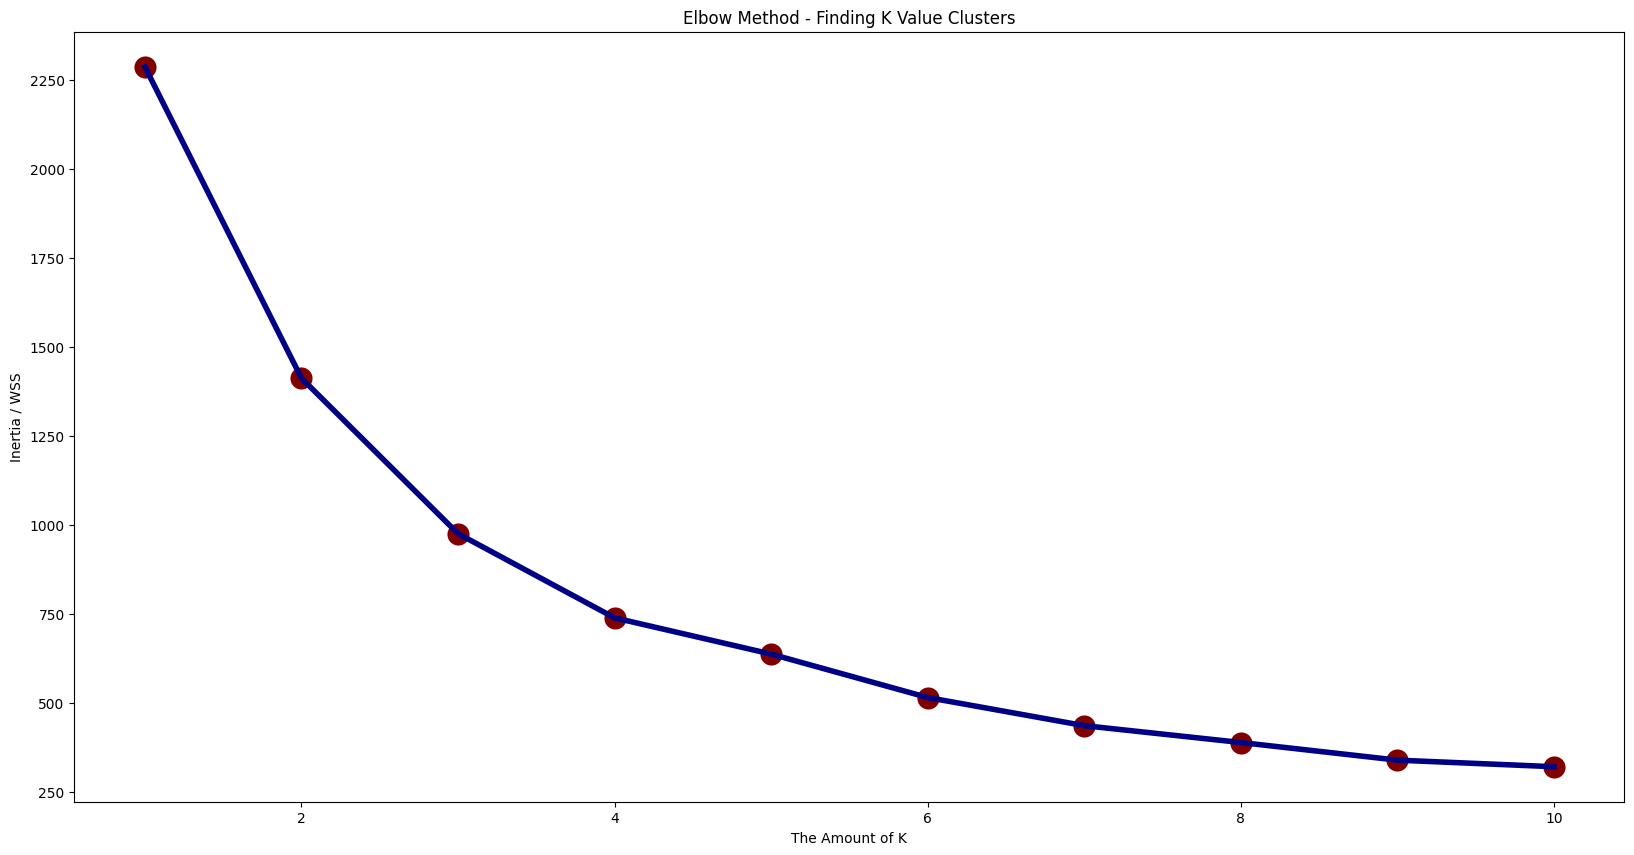

In [18]:
from sklearn.cluster import KMeans

inertia = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=0)
    kmeans.fit(df_scalling.values)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(20, 10))

sns.lineplot(
    x=range(1, 11),
    y=inertia,
    color='#000087',
    linewidth=4
)

sns.scatterplot(
    x=range(1, 11),
    y=inertia,
    s=300,
    color='#800000'
)

plt.title('Elbow Method - Finding K Value Clusters')
plt.xlabel('The Amount of K')
plt.ylabel('Inertia / WSS')

plt.show()

In [19]:
# Dari hasil diatas elbow dipilih pada angka 4,
# karena titik sebelum titik selanjutnya memiliki gap yang konstan
# atau titik setelah lekukan tajam sebelum mendatar

from sklearn.cluster import KMeans

kmeans_elbow = KMeans(n_clusters=4, random_state=0)
kmeans_elbow.fit(df_scalling.values)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",4
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",0
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


In [20]:
#taruh hasil k-means elbow method ke df dengan nama kolom cluster_elbow
df['cluster_elbow'] = kmeans_elbow.labels_

In [21]:
df

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id,cluster_elbow
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5,0,1
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5,1,0
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5,2,0
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6,3,0
4,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5,4,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1138,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6,1592,1
1139,6.8,0.620,0.08,1.9,0.068,28.0,38.0,0.99651,3.42,0.82,9.5,6,1593,1
1140,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5,1594,1
1141,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6,1595,3


<Axes: xlabel='pH', ylabel='alcohol'>

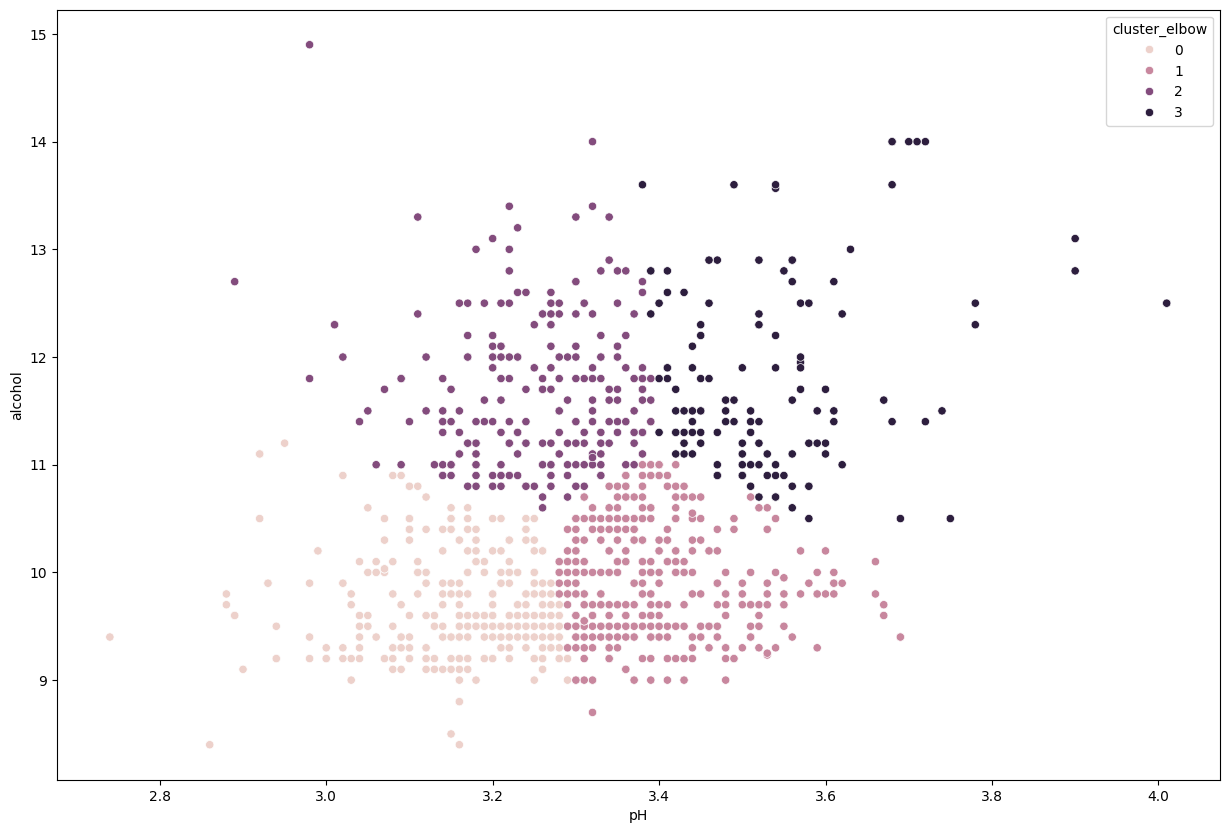

In [22]:
fig, ax = plt.subplots(figsize=(15,10))
sns.scatterplot(data=df, x='pH', y='alcohol', hue='cluster_elbow')

### Bandingkan hasil dengan label anotator

<Axes: xlabel='pH', ylabel='alcohol'>

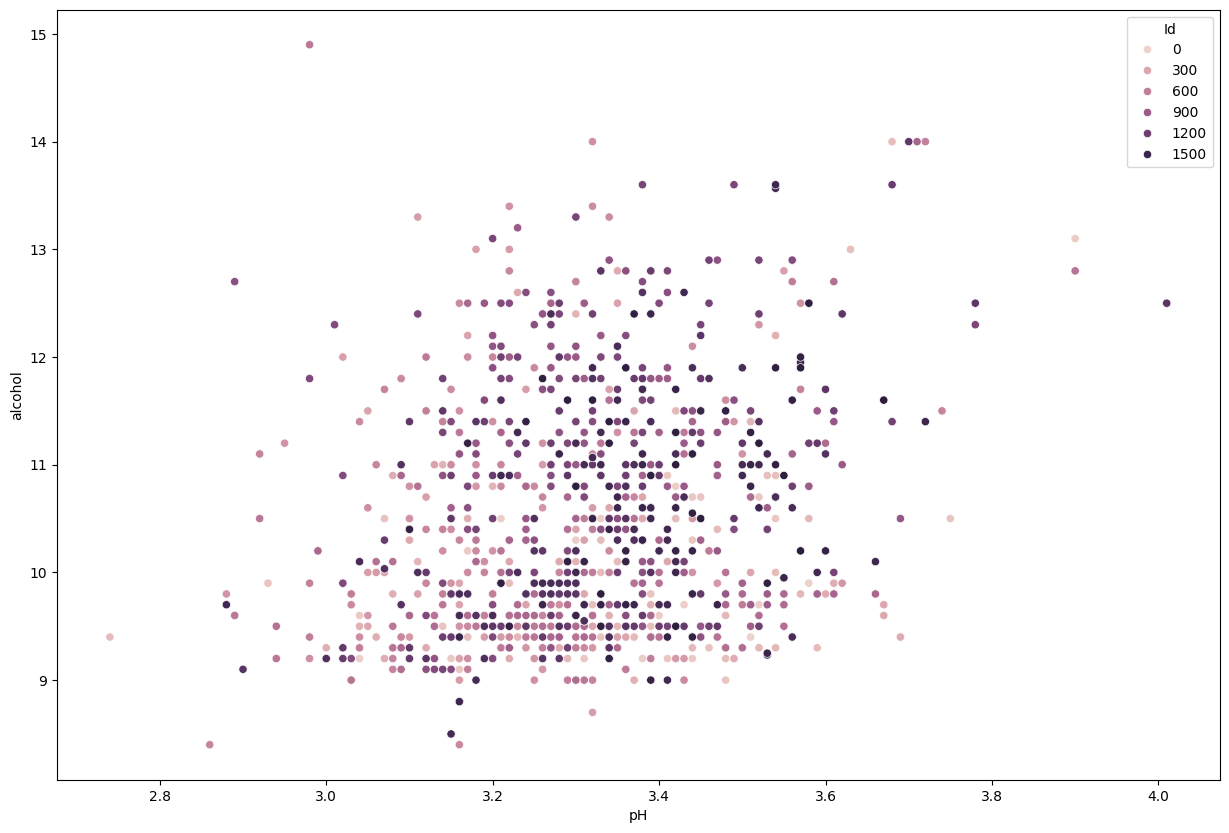

In [23]:
fig, ax = plt.subplots(figsize=(15,10))
sns.scatterplot(data=df, x='pH', y='alcohol',hue='Id')

### Hasil diatas ketika menggunakan elbow ialah optimal, karena cluster cocok dengan label anotator yang telah tersedia di deskripsi. Dengan kondisi :
1. Cluster 0 -> Normal
2. Cluster 1 -> Fat
3. Cluster 2 -> Slim
4. Cluster 3 -> Obese

### 2. Via Score Plot

In [24]:
!pip install yellowbrick

Looking in indexes: https://pypi.org/simple, https://pypi.ngc.nvidia.com


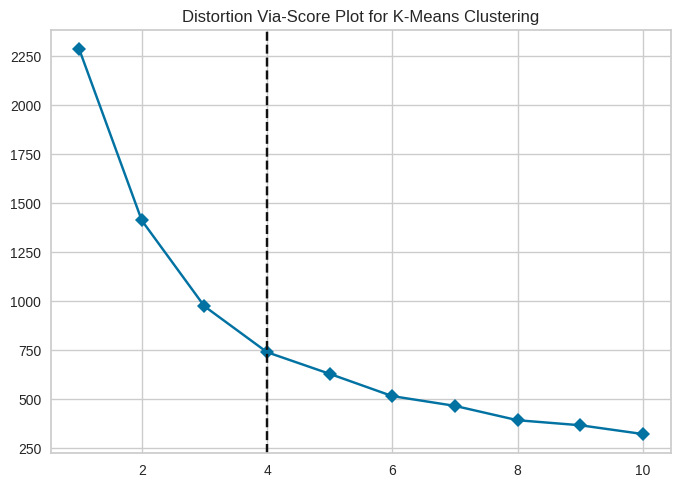

In [25]:
# Via Score Plot
from yellowbrick.cluster import KElbowVisualizer
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

k_means_via = KMeans(random_state=42)

# k is range of number of clusters.
visualizer = KElbowVisualizer(k_means_via, k=(1,11), metric='distortion', timings=False, force_model=True)
visualizer.fit(df_scalling.values)        # Fit the data to the visualizer
plt.title('Distortion Via-Score Plot for K-Means Clustering')
plt.show()

In [26]:
# Dari hasil diatas K-nya dipilih pada angka 3,
# karena titik distorsinya bertemu pada nilai 3 di sumbu x
from sklearn.cluster import KMeans
kmeans_via = KMeans(n_clusters=3, random_state=0)
kmeans_via.fit(df_scalling.values)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",3
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",0
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


In [27]:
#taruh hasil k-means via score method ke df dengan nama kolom cluster_via
df['cluster_via'] = kmeans_via.labels_

In [28]:
df

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id,cluster_elbow,cluster_via
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5,0,1,1
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5,1,0,0
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5,2,0,0
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6,3,0,0
4,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5,4,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1138,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6,1592,1,1
1139,6.8,0.620,0.08,1.9,0.068,28.0,38.0,0.99651,3.42,0.82,9.5,6,1593,1,1
1140,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5,1594,1,1
1141,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6,1595,3,1


## TO DO !
- Lakukan evaluasi pada k-means menggunakan via score secara visualisasi

<Axes: xlabel='pH', ylabel='alcohol'>

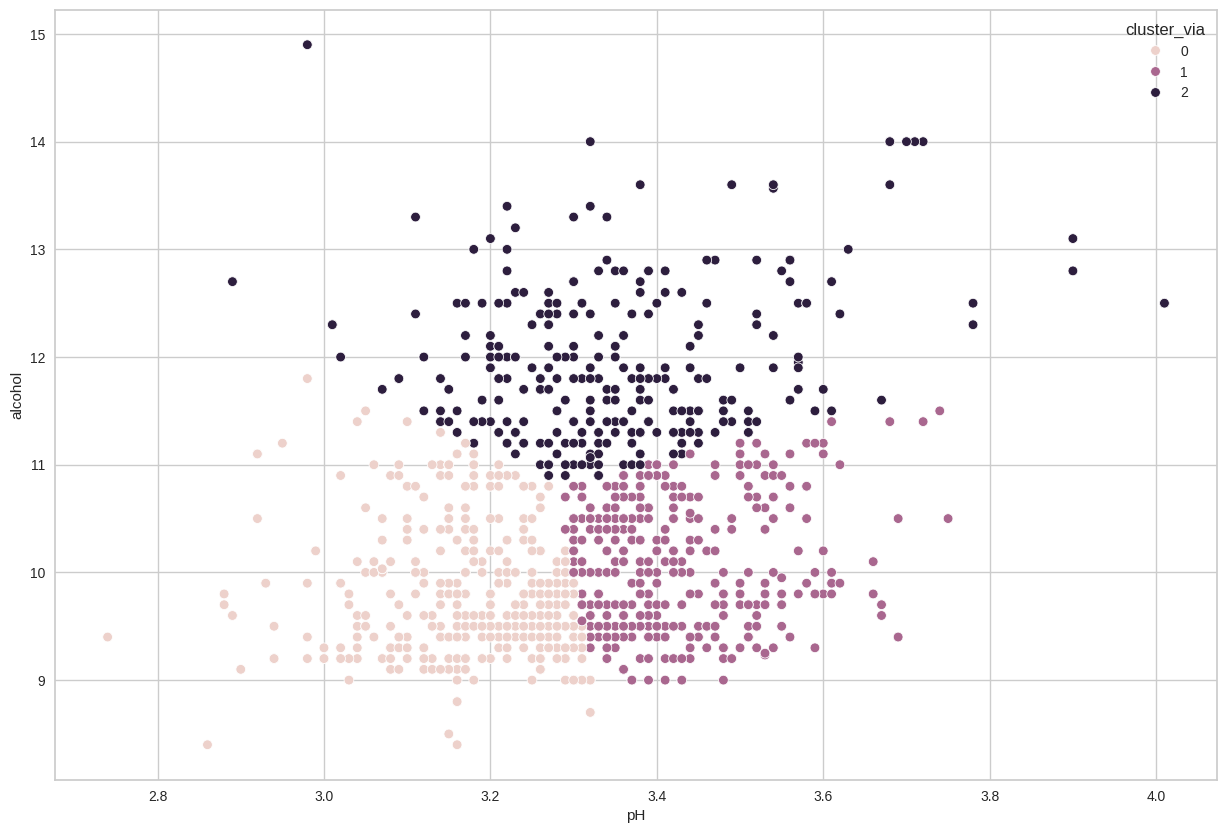

In [29]:
#Lakukan evaluasi setelah dilakukan K-Means
#Bandingkan hasil cluster dengan distribusi data asli
fig, ax = plt.subplots(figsize=(15,10))
sns.scatterplot(data=df, x='pH', y='alcohol', hue='cluster_via')

### Bandingkan dengan label anotator

<Axes: xlabel='pH', ylabel='alcohol'>

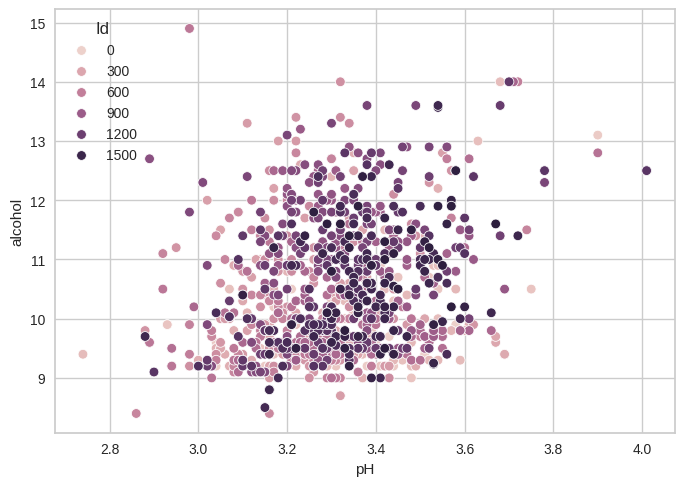

In [30]:
# Bandingkan dengan label anotator
sns.scatterplot(data=df, x='pH', y='alcohol', hue='Id')

### Tulis Interpretasi dari hasil evaluasi diatas :
### Isi disini

1. Scatter plot menunjukkan bahwa distribusi data wine tersebar pada rentang pH sekitar 3.0–3.6 dan kadar alcohol sekitar 9–12, sehingga sebagian besar sampel wine terkonsentrasi pada area tersebut.

2. Tidak terlihat pola hubungan linear yang sangat kuat antara variabel pH dan alcohol, karena titik data cenderung menyebar secara acak pada area distribusi utama. Hal ini menunjukkan bahwa kenaikan kadar alcohol tidak selalu diikuti oleh perubahan nilai pH secara signifikan.

3. Sebagian besar sampel terkumpul pada nilai pH menengah dengan kadar alcohol moderat, yang menandakan karakteristik umum dataset wine berada pada kondisi stabil.

4. Terdapat beberapa titik data yang berada jauh dari pusat persebaran (outlier), terutama pada kadar alcohol yang lebih tinggi, yang menunjukkan adanya beberapa sampel wine dengan karakteristik berbeda dibanding mayoritas data.

5. Persebaran data yang cukup luas menunjukkan bahwa dataset memiliki variasi karakteristik yang baik untuk dilakukan proses clustering menggunakan algoritma K-Means guna mengidentifikasi kelompok wine berdasarkan kemiripan fitur.

### Thank you :)